# Harmonic Balance for Nonlinear FBS Coupling

A multi-harmonic-balance (HBM) solver for nonlinear frequency-based substructuring
is implemented in `pyfbs.nonlinearFBS`. It traces the periodic steady-state response
of an assembly whose substructures are described **only by their admittances**
$\mathbf{Y}(\omega)$ and joined through a **localized nonlinear interface force**
(nonlinear joints, bushings, contact, ...).

In this tutorial two numerically generated substructures of the pyFBS lab testbench
are coupled by a **cubic (hardening) spring**. A virtual point transformation (VPT)
first condenses each interface onto six collocated generalized DoFs
$[u_x, u_y, u_z, r_x, r_y, r_z]$; the spring then acts on the relative virtual-point
gap. Because the interface force is nonlinear there is no closed-form LM-FBS assembly:
the forced response is followed by Alternating Frequency-Time (AFT) harmonic balance
with pseudo-arclength continuation, directly in physical rad/s.

This mirrors the linear *07_FBS_coupling* tutorial; see *05_VPT* and
*03_FRF_synthetization* for the VPT and FRF-synthesis details reused below, and
`nonlinearFBS_overview.ipynb` for the solver internals.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# inline by default (diagnostic plots stay in the notebook); the FRC plot cell
# switches to an external Qt window.
%matplotlib inline

import pyfbs
from pyfbs.nonlinearFBS import (
    FBS_System, Fourier_Real, FourierOmegaPoint, FBSProblem,
    ModalVPFRF, AFT, HarmonicBalanceMethod,
)
from pyfbs.nonlinearFBS.numerical_continuation.corrector_step import ArcLengthParameterization
from pyfbs.nonlinearFBS.numerical_continuation.predictor_step import TangentPredictorBordered

## Data import

Download the predefined lab-testbench datasets and read the channel / impact /
virtual-point definitions for substructures A and B.

In [38]:
pyfbs.io.download_lab_testbench()

100%|██████████| 10/10 [00:00<00:00, 11742.17it/s]


100%|██████████| 3/3 [00:00<00:00, 6410.04it/s]


100%|██████████| 10/10 [00:00<00:00, 11745.46it/s]


In [39]:
pos_xlsx = r"./lab_testbench/Measurements/coupling_example.xlsx"

df_chn_A = pd.read_excel(pos_xlsx, sheet_name="Channels_A")
df_imp_A = pd.read_excel(pos_xlsx, sheet_name="Impacts_A")

df_chn_B = pd.read_excel(pos_xlsx, sheet_name="Channels_B")
df_imp_B = pd.read_excel(pos_xlsx, sheet_name="Impacts_B")

df_vp    = pd.read_excel(pos_xlsx, sheet_name="VP_Channels")
df_vpref = pd.read_excel(pos_xlsx, sheet_name="VP_RefChannels")

## 3D overview

Open a 3D viewer and show both substructures with their channels and impacts.

In [40]:
view3D = pyfbs.display.View3D(show_origin=False, show_axes=False,
                             shape=(1, 2), title="Substructures A and B")

view3D.plot.subplot(0, 0)
view3D.plot.add_text("A structure", position="upper_left", font_size=10, color="k", name="A_text")
view3D.add_stl(r"./lab_testbench/STL/A.stl", color="#83afd2", name="A")
view3D.show_imp(df_imp_A, scale=1000)   # marker positions are in metres, STL in mm -> scale=1000
view3D.show_chn(df_chn_A, scale=1000)
view3D.plot.isometric_view()

# show_imp/show_chn keep a SINGLE global marker actor for the whole View3D, so by
# default B's markers would be merged into A's actor and moved to B's subplot (and
# A's removed). Reset the handles so B's markers build fresh in their own subplot.
view3D.global_imp = None
view3D.global_chn = None

view3D.plot.subplot(0, 1)
view3D.plot.add_text("B structure", position="upper_left", font_size=10, color="k", name="B_text")
view3D.add_stl(r"./lab_testbench/STL/B.stl", color="#83afd2", name="B")
view3D.show_imp(df_imp_B, scale=1000)
view3D.show_chn(df_chn_B, scale=1000)
view3D.plot.isometric_view()

## Numerical model

Create an MK model for each substructure from its ANSYS `.rst` / `.full` pair
(see *03_FRF_synthetization* for details).

In [41]:
MK_A = pyfbs.mck.Model.from_ansys(r"./lab_testbench/FEM/A.rst", r"./lab_testbench/FEM/A.full",
                                  no_modes=100, allow_pickle=True, recalculate=False, mesh_scale=1)
MK_B = pyfbs.mck.Model.from_ansys(r"./lab_testbench/FEM/B.rst", r"./lab_testbench/FEM/B.full",
                                  no_modes=100, allow_pickle=True, recalculate=False, mesh_scale=1)

Snap the channel and impact locations to the nearest FE node.

<div class="alert alert-block alert-warning">
    <i class="fa fa-exclamation-triangle" aria-hidden="true"></i>
    <b>Warning!</b> When performing numerical cases always make sure channels and impacts are aligned with FE nodes!
</div>

In [42]:
df_chn_A = MK_A.update_locations_df(df_chn_A, scale=1)
df_imp_A = MK_A.update_locations_df(df_imp_A, scale=1)
df_chn_B = MK_B.update_locations_df(df_chn_B, scale=1)
df_imp_B = MK_B.update_locations_df(df_imp_B, scale=1)

Synthesize the FRFs of each substructure on the updated locations. A fine
frequency resolution is used so the lightly damped resonances are well resolved.

In [43]:
f_resolution  = 0.05    # FRF resolution Delta f [Hz] (smaller = denser grid)
modal_damping = 0.003   # modal damping ratio

MK_A.frf_synth(df_chn_A, df_imp_A, f_start=0, f_resolution=f_resolution, modal_damping=modal_damping)
MK_B.frf_synth(df_chn_B, df_imp_B, f_start=0, f_resolution=f_resolution, modal_damping=modal_damping)

freq  = MK_A.freq
omega = 2 * np.pi * freq

## Virtual point transformation

The interface is condensed onto six collocated generalized DoFs per substructure so
the two interfaces match exactly. The VPT is built from the channel / impact and
virtual-point definitions and applied to the synthesized FRFs (see *05_VPT*).

In [44]:
vpt_A = pyfbs.interface.VPT(df_chn_A, df_imp_A, df_vp, df_vpref)
vpt_B = pyfbs.interface.VPT(df_chn_B, df_imp_B, df_vp, df_vpref)

vpt_A.apply_vpt(MK_A.freq, MK_A.frf)
vpt_B.apply_vpt(MK_B.freq, MK_B.frf)

Y_A = vpt_A.frf   # (N_freq, nA, nA): A reference DoFs first, 6 VP interface DoFs last
Y_B = vpt_B.frf   # (N_freq, nB, nB): 6 VP interface DoFs first, B reference DoFs after

## Uncoupled admittance and interface coupling

Stack the substructure admittances into the block-diagonal uncoupled admittance

$$\mathbf{Y}^{A|B}(\omega) = \begin{bmatrix} \mathbf{Y}^{A} & \mathbf{0} \\ \mathbf{0} & \mathbf{Y}^{B} \end{bmatrix},$$

and define the signed-Boolean matrix $\mathbf{B}$ that picks the six matching
virtual-point DoF pairs (relative interface gap $\,x_r = \mathbf{B}\,u$). The A
interface is the last six DoFs of A; the B interface the first six of B.

In [45]:
N_IF = 6   # virtual-point interface DoFs: [ux, uy, uz, rx, ry, rz]

nA, nB = Y_A.shape[1], Y_B.shape[1]
N = nA + nB

Y = np.zeros((len(freq), N, N), dtype=complex)
Y[:, :nA, :nA] = Y_A
Y[:, nA:, nA:] = Y_B

# signed-Boolean coupling of the six VP DoFs.
A_if = np.arange(nA - N_IF, nA)     # A interface = last 6 DoFs of A
B_if = np.arange(nA, nA + N_IF)     # B interface = first 6 DoFs of B
B_coupling = np.zeros((N_IF, N))
B_coupling[np.arange(N_IF), A_if] =  1.0
B_coupling[np.arange(N_IF), B_if] = -1.0

# response (out) and excitation (inp) DoFs in the full block-diagonal layout
# [ A ref | A interface(6) | B interface(6) | B ref ].
out_full = 0            # first A reference DoF (where we read the response)
inp_full = nA + N_IF    # first B reference DoF (where the harmonic force is applied)

Inspect the coupling matrix to confirm the correct DoFs are matched (+1 on A,
-1 on B).

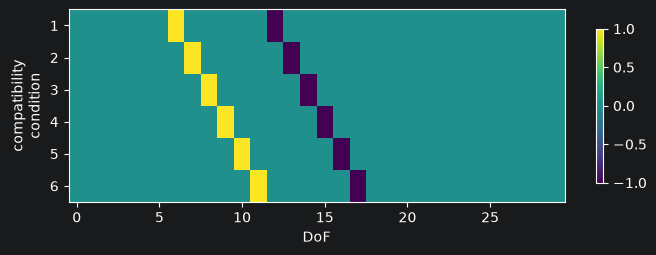

In [46]:
plt.figure(figsize=(8, 2.5))
plt.imshow(B_coupling, aspect="auto")
plt.colorbar(shrink=0.8)
plt.xlabel("DoF")
plt.ylabel("compatibility\ncondition")
plt.yticks(np.arange(N_IF), np.arange(1, N_IF + 1));

## The nonlinear interface: a cubic spring

The substructures are joined by a hardening cubic bushing acting elementwise on each
interface DoF of the relative gap $x_r = \mathbf{B}\,u$:

$$\mathbf{f}_{nl} = \mathbf{k} * x_{rel} + \boldsymbol{\alpha} * x_{rel}^{3}.$$

Harmonic balance solves for the Fourier
coefficients $\mathbf{Q}_{rel}$ of $x_{rel}$ through the FBS-HBM residual

$$\mathbf{R} = \mathbf{Q}_{rel} + \mathbf{B}\,\mathbf{Y}^{A|B}\,\mathbf{B}^{T}\,\mathbf{F}_{nl}(\mathbf{Q}_{rel}) - \mathbf{B}\,\mathbf{Y}^{A|B}\,\mathbf{F}^{ext} = \mathbf{0}$$

A problem is defined by subclassing `FBS_System`: it declares the coupling matrix and
the per-DoF interface force together with its (diagonal) Jacobians. There is no
velocity dependence, so the velocity-Jacobian is zero.

In [47]:
class CubicSpringCoupling(FBS_System):
    """Hardening cubic bushing on the 6-DoF virtual-point gap  x_rel = B u:

        f_nl = k * (x_rel + alpha * x_rel**3)      (elementwise, per interface DoF)

    The per-DoF cubic term couples the harmonics and bends the resonance, so the
    converged branch is a genuine nonlinear forced-response curve, not a receptance.
    """
    is_real_valued = True

    def __init__(self, B_coupling, k_diag, alpha_diag, inp_full, out_full,
                 F0=1.0, sample_number=1024):
        self.B_coupling    = B_coupling              # (6, N) signed-Boolean coupling
        self.k_diag        = np.asarray(k_diag)      # (6,) linear stiffness
        self.alpha_diag    = np.asarray(alpha_diag)  # (6,) cubic coefficient
        self.inp_full      = inp_full                # excitation DoF (full layout)
        self.out_full      = out_full                # response   DoF (full layout)
        self.F0            = F0                       # harmonic force amplitude [N]
        self.sample_number = sample_number           # AFT time samples

    def external_term(self, tau):
        # harmonic point force F0*cos(tau) at the excitation DoF
        f = np.zeros((len(tau), self.B_coupling.shape[1], 1))
        f[:, self.inp_full, 0] = self.F0 * np.cos(tau)
        return f

    def interface_force(self, u_rel, udot_rel, tau):
        # f_i = k_i (x_i + alpha_i x_i^3); broadcast (6,) over the time axis of u_rel
        k     = self.k_diag[None, :, None]
        alpha = self.alpha_diag[None, :, None]
        return k * u_rel + alpha * u_rel ** 3               # (Nt, 6, 1)

    def jacobian_interface_force(self, u_rel, udot_rel, tau):
        # df_i/dx_i = k_i + 3 alpha_i x_i^2) -> diagonal (each DoF self-coupled)
        n_int = self.B_coupling.shape[0]
        diag  = self.k_diag[None, :] + 3.0 * self.alpha_diag[None, :] * u_rel[:, :, 0] ** 2
        J = np.zeros((len(tau), n_int, n_int))
        d = np.arange(n_int)
        J[:, d, d] = diag
        return J

    def jacobian_interface_force_qdot(self, u_rel, udot_rel, tau):
        n_int = self.B_coupling.shape[0]
        return np.zeros((len(tau), n_int, n_int))             # no velocity dependence

## Coupling parameters

Choose the spring stiffness, the cubic strength, the forcing amplitude and the
retained harmonics. A cubic force generates only odd harmonics, so harmonics
$[1, 3, 5, 7]$ are balanced.

In [48]:
k_trans, k_rot         = 1.0e3, 1.0e3   # linear stiffness  [N/m] / [Nm/rad]
alpha_trans, alpha_rot = 1.0e6, 1.0e08     # cubic coefficient [1/m^2] / [1/rad^2]
F0                     = 50.0           # harmonic force amplitude [N]
HARMONICS              = [1, 3, 5, 7]   # cubic forcing -> odd harmonics

k_diag     = np.array([k_trans, k_trans, k_trans, k_rot, k_rot, k_rot])
alpha_diag = np.array([alpha_trans, alpha_trans, alpha_trans, alpha_rot, alpha_rot, alpha_rot])

system = CubicSpringCoupling(B_coupling, k_diag, alpha_diag, inp_full, out_full, F0=F0)

## Harmonic balance solve

Pick the FRF source -- here `ModalVPFRF`, which folds the VPT into the FE mode shapes
and synthesizes the virtual-point admittance directly at the exact harmonics
$n\omega$ (the physical admittance is never assembled). The same `system` could
equally be driven by `ExperimentalFRF(omega, Y)` on the measured-style grid.

Tell the Fourier layer which harmonics to balance, then assemble the problem
(`system` + FRF provider + `AFT`) and the continuation driver.

In [49]:
provider = ModalVPFRF.from_substructures(
    [(MK_A, vpt_A, df_chn_A, df_imp_A),
     (MK_B, vpt_B, df_chn_B, df_imp_B)],
    modal_damping=modal_damping)

HarmonicBalanceMethod.update_dependencies(HARMONICS, system.sample_number)

problem = FBSProblem(system, provider, AFT())
solver  = HarmonicBalanceMethod(
    harmonics=HARMONICS, freq_domain_ode=problem,
    corrector_parameterization=ArcLengthParameterization,
    predictor=TangentPredictorBordered)

Set the continuation band in **Hz** and convert to **rad/s** (the solver works in rad/s).
The cold start begins above the highest mode and sweeps downward across the whole band.
Keep `f_lo` above the rigid-body region — sweeping to ~0 Hz makes Newton stall on the
DC / rigid-body response.

In [50]:
# Continuation band in Hz -> rad/s. Sweep the whole structural band; start above the
# highest mode and keep f_lo above the rigid-body region (do NOT go to ~0 Hz).
f_lo, f_hi = 20.0, 1000.0
w_lo, w_hi = 2.0 * np.pi * f_lo, 2.0 * np.pi * f_hi
print(f"Continuation band: {f_lo:.1f} .. {f_hi:.1f} Hz  ({w_lo:.1f} .. {w_hi:.1f} rad/s)")

Continuation band: 20.0 .. 1000.0 Hz  (125.7 .. 6283.2 rad/s)


Seed the branch with a cold (zero-amplitude) start at the top of the window and
sweep $\omega$ downward with arc-length continuation.

In [51]:
ig = FourierOmegaPoint.zero_amplitude(dimension=N_IF, omega=w_hi)
rd = FourierOmegaPoint.new_from_first_harmonic(np.zeros((N_IF, 1), complex), omega=-1.0)

ss = solver.solve_and_continue(
    initial_guess                 = ig,
    initial_reference_direction   = rd,
    maximum_number_of_solutions   = 10000,
    angular_frequency_range       = [w_lo, w_hi],
    solver_kwargs                 = {"maximum_iterations": 300, "absolute_tolerance": 1e-6},
    step_length_adaptation_kwargs = {"base": 4.0,
                                     "initial_step_length": 2 * np.pi, # expects rad/s
                                     "maximum_step_length": 2 * np.pi,
                                     "minimum_step_length": 1e-7,
                                     "goal_number_of_iterations": 3},
    jacobian_update_frequency     = 1,
)

	iterations 2 	Δω -1.00e+00progress 11.908 % 	iterations 2 	Δω -1.00e+00progress 11.206 % 	iterations 47 	Δω -1.00e+00progress 9.362 % 	iterations 2 	Δω -1.00e+00progress 9.220 % 	iterations 2 	Δω -1.00e+00progress 9.400 % 	iterations 33 	Δω -1.00e+00progress 9.630 % 	iterations 2 	Δω -1.00e+00progress 9.780 % 	iterations 2 	Δω -1.00e+00

C:\Users\yanni\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\linalg\_linalg.py:2768: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)


Newton-Raphson: maximum iterations reached (300)
Newton-Raphson: maximum iterations reached (300)
progress 10.100 % 	iterations 2 	Δω 9.96e-01progress 10.240 % 	iterations 4 	Δω 9.94e-01progress 10.380 % 	iterations 3 	Δω 9.57e-01progress 10.530 % 	iterations 5 	Δω 8.36e-01progress 10.650 % 	iterations 5 	Δω 5.19e-01progress 10.800 % 	iterations 3 	Δω -4.79e-01progress 10.950 % 	iterations 3 	Δω -8.87e-01progress 11.100 % 	iterations 3 	Δω -9.90e-01progress 11.240 % 	iterations 3 	Δω -9.99e-01progress 11.410 % 	iterations 3 	Δω -1.00e+00progress 11.440 % 	iterations 31 	Δω -9.94e-01progress 11.600 % 	iterations 2 	Δω 9.69e-01progress 11.760 % 	iterations 3 	Δω 9.98e-01progress 11.920 % 	iterations 3 	Δω 9.95e-01progress 12.080 % 	iterations 3 	Δω 9.74e-01progress 12.230 % 	iterations 4 	Δω 9.09e-01progress 12.390 % 	iterations 3 	Δω 8.47e-01progress 12.560 % 	iterations 3 	Δω 7.63e-01progress 12.730 % 	iterations 3 	Δω 6.46e-01progress 12.900 % 	iterations 3 	Δω 4.89e-01progress 13.070

## Results

For each converged branch point, reconstruct the full physical response and take the
peak amplitude of the output DoF over one period -- the nonlinear forced response at
this excitation level.

In [52]:
f_solver = np.array(ss.omega) / (2.0 * np.pi)        # rad/s -> Hz
amp = np.zeros(len(f_solver))
for i, (four, w) in enumerate(zip(ss.fourier, ss.omega)):
    full = problem.compute_full_response(four, w)
    Fourier_Real.compute_time_series(full)
    amp[i] = float(np.max(np.abs(full.time_series[:, system.out_full, 0])))

In [53]:
# FRC in an external pop-out window (pan/zoom/save toolbar)
%matplotlib qt

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(f_solver, amp, "-", color="#2ca02c", lw=1.2,
            label="cubic spring NFRC (HBM solver)")
ax.set_xlim(f_lo, f_hi)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Amplitude |q|  [m]")
ax.set_title("Cubic-spring FBS coupling of testbench A + B")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()

## Full-mesh response animation

The converged solution can be replayed on the full FE meshes, exactly like a
mode-shape animation but reconstructed from all retained harmonics -- the actual
periodic operating motion at the chosen excitation frequency.

In [54]:
from pyfbs.nonlinearFBS.examples.response_visualization import animate_response_at_frequency

target_freq = float(f_solver[np.argmax(amp)])     # peak-amplitude branch point
substructures = [
    {"model": MK_A, "vpt": vpt_A, "df_imp": df_imp_A, "n_reduced": nA},
    {"model": MK_B, "vpt": vpt_B, "df_imp": df_imp_B, "n_reduced": nB},
]

# show_origin=False: View3D's origin triad is sized for millimetres while the mesh is
# in metres, so the default triad would dwarf the model.
view_an = pyfbs.display.View3D(title="Cubic-spring coupling -- response animation",
                               show_origin=False)
animate_response_at_frequency(
    view_an, problem, ss, substructures,
    target_frequency=target_freq, modal_damping=modal_damping,
    r_scale=0.08, run_animation=True)

Animating full-mesh response at 29.56 Hz (nearest to target 29.56 Hz; branch point 1267 of 1503).


(1267, 29.560461830339364)